# MLP Depth vs Width: Does Architecture Shape Matter More Than Size?
**Author:** Jobin Bose  
**Dataset:** Energy Efficiency (Tsanas & Xifara, 2012)  
**GitHub:** *https://github.com/Jobin85/MLP-Depth-vs-Width*

---

## How to Use This Tutorial

Run every cell top-to-bottom. The notebook will:
1. Load and preprocess the Energy Efficiency dataset  
2. Train linear **and tree-based** baselines  
3. Sweep MLP depth, then width, then a depth×width grid  
4. Run multi-seed robustness checks  
5. Evaluate the final selected model on a held-out test set  

Before running, install dependencies:
```
pip install -r requirements.txt
```

Place `ENB2012_data.xlsx` in the **same folder** as this notebook.

## 1  Setup and Imports

In [1]:
%matplotlib inline

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel("ERROR")
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

## 2  Reproducibility

Neural networks have three sources of randomness: weight initialisation, mini-batch ordering, and certain GPU operations.  
We fix all of them with a single helper. **Do not** embed the seed inside the model builder — that would break the multi-seed experiment later.

In [2]:
def set_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

SEED = 42
set_all_seeds(SEED)

BATCH_SIZE   = 64
MAX_EPOCHS   = 150
PATIENCE     = 10
ROBUSTNESS_SEEDS = [7, 21, 42, 84, 123]

# ── Colorblind-safe palette (Wong 2011) ──────────────────────
DEPTH_COLOURS = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
WIDTH_COLOURS = ['#F0E442', '#56B4E9', '#009E73', '#D55E00', '#0072B2']

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "white", "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 9, "lines.linewidth": 1.8,
})
print("Seeds and settings configured.")

Seeds and settings configured.


## 3  Theoretical Background

### Why does architecture choice matter?

The **Universal Approximation Theorem** (Hornik et al., 1989; Cybenko, 1989) tells us that a single hidden layer with enough neurons can, in principle, approximate any continuous function on a compact domain.  
However, *in practice* the number of neurons required can be astronomically large.

**Depth** gives networks the ability to compose simple functions into complex hierarchical ones — each layer builds on abstractions from the previous. A classic example: pixel edges → corners → shapes → objects.  
**Width** increases representational power within a single transformation step; it is better at capturing many independent patterns in parallel.

### The vanishing gradient problem and ReLU

When networks are deep and use sigmoid/tanh activations, gradients shrink exponentially as they propagate backwards. This is the **vanishing gradient problem** (Hochreiter, 1998).  
**ReLU** (Rectified Linear Unit) partially solves this: its gradient is 1 for positive inputs and 0 otherwise, so it does not compress gradients in the way sigmoid does. This is why ReLU is the default activation for modern MLPs.

### Glorot / Xavier initialisation

Poor weight initialisation can cause gradients to explode or vanish even before training begins. **Glorot & Bengio (2010)** derived an initialisation scheme that keeps the variance of activations roughly constant across layers:

  Var(W) = 2 / (fan_in + fan_out)

This is what we use throughout this notebook.

### Key question this tutorial addresses

Given a fixed computational budget (similar parameter count), should we go **deep** (many layers, few neurons each) or **wide** (few layers, many neurons each)?

## 4  Data Loading and Preprocessing

In [3]:
DATASET_PATH = "ENB2012_data.xlsx"

# Provide a clear error message if the file is missing
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATASET_PATH}'.\n"
        "Download it from: https://archive.ics.uci.edu/ml/datasets/Energy+efficiency\n"
        "Then place ENB2012_data.xlsx in the same directory as this notebook."
    )

df = pd.read_excel(DATASET_PATH)
df.columns = [
    "RelativeCompactness","SurfaceArea","WallArea","RoofArea",
    "OverallHeight","Orientation","GlazingArea",
    "GlazingAreaDistribution","Y1","Y2"
]
print("Shape:", df.shape)
display(df.head())
display(df.describe().round(2))

Shape: (768, 10)


,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,Y1,Y2
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


### Preprocessing decisions

**One-hot encoding Orientation and GlazingAreaDistribution**  
Although these columns look numeric, their values are discrete category labels (e.g. orientation 2, 3, 4, 5 do not imply "orientation 4 is twice as much as orientation 2"). Treating them as continuous would introduce a false ordinal relationship. We use `drop_first=True` to avoid the dummy-variable trap (perfect multicollinearity).

**Standardisation**  
Neural networks are sensitive to feature scale: a feature with range 0–800 will dominate gradient steps over one with range 0–1. We standardise all inputs to zero mean and unit variance using a `StandardScaler`.  

**Data leakage warning:** The scaler must be fitted only on training data, then applied to validation and test. Fitting on the full dataset would leak test statistics into training.

In [4]:
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=["Orientation","GlazingAreaDistribution"], drop_first=True)
print("Shape after encoding:", df.shape)

X  = df.drop(columns=["Y1","Y2"])
y1 = df["Y1"].values
y2 = df["Y2"].values

# ── 70 / 15 / 15 split ──────────────────────────────────────
X_train_full, X_test_raw, y1_train_full, y1_test, y2_train_full, y2_test = train_test_split(
    X, y1, y2, test_size=0.15, random_state=SEED
)
val_frac = 0.15 / 0.85
X_train_raw, X_val_raw, y1_train, y1_val, y2_train, y2_val = train_test_split(
    X_train_full, y1_train_full, y2_train_full,
    test_size=val_frac, random_state=SEED
)
print(f"Train: {X_train_raw.shape[0]}  Val: {X_val_raw.shape[0]}  Test: {X_test_raw.shape[0]}")

# ── Standardise (fit on train only) ─────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

N_FEATURES = X_train.shape[1]
print("Input features:", N_FEATURES)

Shape after encoding: (768, 16)
Train: 536  Val: 116  Test: 116
Input features: 14


## 5  Baseline Models

We establish baselines **before** introducing MLPs. Any MLP result must be interpreted relative to these.

We include:
- **Linear Regression** — the simplest possible model; reveals linear structure.
- **Ridge Regression** — adds L2 regularisation; useful when features are collinear.
- **Random Forest** — a strong non-linear baseline for tabular data. On many tabular datasets, tree ensembles outperform MLPs. If our MLP cannot beat a Random Forest, the added complexity is hard to justify.

> **Tutorial tip:** Always include a tree-based baseline on tabular data. It is a common mistake to compare MLPs only to linear models — this makes the MLP look more impressive than it might deserve.

In [5]:
def eval_baseline(model, Xtr, ytr, Xv, yv):
    model.fit(Xtr, ytr)
    return float(mean_squared_error(yv, model.predict(Xv)))

baselines = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1)":       Ridge(alpha=1.0),
    "Ridge (α=10)":      Ridge(alpha=10.0),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=SEED),
}

rows = []
for name, mdl in baselines.items():
    from sklearn.base import clone
    v1 = eval_baseline(clone(mdl), X_train, y1_train, X_val, y1_val)
    v2 = eval_baseline(clone(mdl), X_train, y2_train, X_val, y2_val)
    rows.append({"Model":name,"Val MSE Y1":v1,"Val MSE Y2":v2})

baseline_df = pd.DataFrame(rows).set_index("Model")
display(baseline_df.round(3))

BEST_BASELINE_VAL_Y1  = baseline_df["Val MSE Y1"].min()
BEST_BASELINE_VAL_Y2  = baseline_df["Val MSE Y2"].min()
BEST_BASELINE_NAME_Y1 = baseline_df["Val MSE Y1"].idxmin()
BEST_BASELINE_NAME_Y2 = baseline_df["Val MSE Y2"].idxmin()
print(f"Best baseline on validation — Y1: {BEST_BASELINE_NAME_Y1} ({BEST_BASELINE_VAL_Y1:.3f})")
print(f"Best baseline on validation — Y2: {BEST_BASELINE_NAME_Y2} ({BEST_BASELINE_VAL_Y2:.3f})")

,Val MSE Y1,Val MSE Y2
Model,,
Linear Regression,4.367,7.472
Ridge (α=1),4.349,7.570
Ridge (α=10),4.611,8.134
Random Forest,0.196,1.582


Best baseline on validation — Y1: Random Forest (0.196)
Best baseline on validation — Y2: Random Forest (1.582)


### 5-fold cross-validation on Random Forest

With only 768 samples, a single train/val split may be noisy. Cross-validation gives a more reliable estimate of baseline generalisation performance.

In [6]:
rf_cv = RandomForestRegressor(n_estimators=100, random_state=SEED)
# Use negative MSE (sklearn convention) on training set only (no test leakage)
X_trainval = np.vstack([X_train, X_val])
y1_trainval = np.concatenate([y1_train, y1_val])
scores_y1 = -cross_val_score(rf_cv, X_trainval, y1_trainval,
                              cv=5, scoring="neg_mean_squared_error")
print(f"RF 5-fold CV MSE Y1: {scores_y1.mean():.3f} ± {scores_y1.std():.3f}")

RF 5-fold CV MSE Y1: 0.271 ± 0.064


## 6  MLP Architecture Design

### Experiment overview

| Experiment | What varies | What is held fixed |
|---|---|---|
| Depth sweep | Number of layers (1–4) | Total ≈ parameter count |
| Width sweep | Neurons per layer (8–256) | 2 hidden layers |
| Depth × Width grid | Both | — |

### Why match parameter counts in the depth sweep?

If a deeper network has far more parameters, any performance gain might simply come from having more capacity, not from the structural benefit of depth. By keeping parameter counts similar across architectures, we make the comparison fair.

In [7]:
DEPTH_ARCHS = {
    "1 layer  [130]":         [130],
    "2 layers [38,38]":       [38, 38],
    "3 layers [27,27,27]":    [27, 27, 27],
    "4 layers [22,22,22,22]": [22, 22, 22, 22],
}
WIDTH_ARCHS = {
    "Width 8":   [8,   8],
    "Width 32":  [32,  32],
    "Width 64":  [64,  64],
    "Width 128": [128, 128],
    "Width 256": [256, 256],
}
GRID_DEPTHS = [1, 2, 3]
GRID_WIDTHS = [32, 64, 128]

## 6 Figure 1  Architecture Diagram

This figure is included to make the tutorial more visual. It shows what changes when you increase **depth** (more hidden layers) and when you increase **width** (more neurons within a hidden layer).

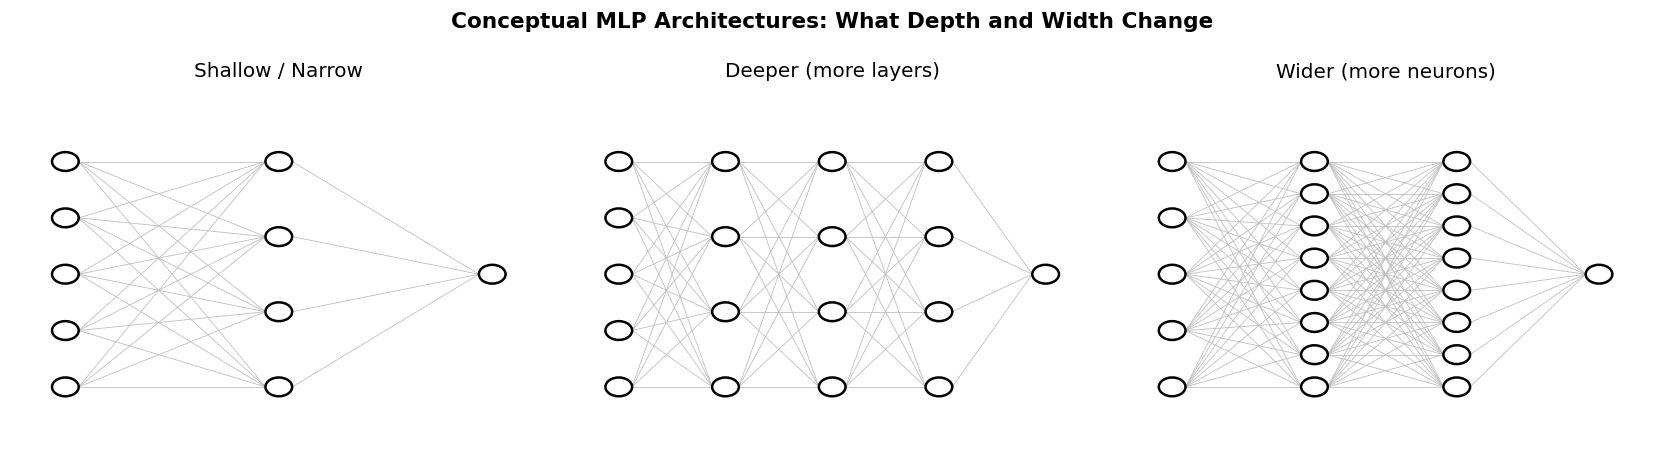

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def draw_network(ax, layer_sizes, title):
    x_positions = np.linspace(0.1, 0.9, len(layer_sizes))
    max_nodes = max(layer_sizes)
    node_radius = 0.025
    for li, (x, size) in enumerate(zip(x_positions, layer_sizes)):
        ys = np.linspace(0.2, 0.8, size) if size > 1 else np.array([0.5])
        for y in ys:
            circle = plt.Circle((x, y), node_radius, fill=False, lw=1.5)
            ax.add_patch(circle)
        if li < len(layer_sizes) - 1:
            next_x = x_positions[li + 1]
            next_ys = np.linspace(0.2, 0.8, layer_sizes[li + 1]) if layer_sizes[li + 1] > 1 else np.array([0.5])
            for y in ys:
                for ny in next_ys:
                    ax.plot([x + node_radius, next_x - node_radius], [y, ny], color='0.75', lw=0.5, zorder=0)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# Small schematic only — not exact experiment sizes
input_nodes, output_nodes = 5, 1
draw_network(axes[0], [input_nodes, 4, output_nodes], 'Shallow / Narrow')
draw_network(axes[1], [input_nodes, 4, 4, 4, output_nodes], 'Deeper (more layers)')
draw_network(axes[2], [input_nodes, 8, 8, output_nodes], 'Wider (more neurons)')

fig.suptitle('Conceptual MLP Architectures: What Depth and Width Change', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_architecture_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7  Model Builder and Training Helpers

### Why Glorot initialisation?

Random initialisation from a standard normal can push activations into saturation regions. Glorot initialisation scales weights so the variance of the signal is approximately preserved across layers, which stabilises early training.

### Why early stopping with `restore_best_weights`?

Early stopping watches validation loss. If it does not improve for `patience=10` epochs, training halts. `restore_best_weights=True` rolls back to the epoch with the lowest validation loss — so the returned model is the best checkpoint, not just the last one.

In [9]:
def build_model(hidden_layers, n_features=None, seed=None):
    if n_features is None:
        n_features = N_FEATURES
    tf.keras.backend.clear_session()
    init = keras.initializers.GlorotUniform(seed=seed)
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for i, n in enumerate(hidden_layers):
        model.add(layers.Dense(n, activation="relu",
                               kernel_initializer=init, name=f"hidden_{i+1}"))
    model.add(layers.Dense(1, name="output"))
    return model

def train_architecture(hidden_layers, y_train, y_val, seed=SEED, verbose=0):
    set_all_seeds(seed)
    model = build_model(hidden_layers, seed=seed)
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
    cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                       restore_best_weights=True, min_delta=1e-4)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=[cb], verbose=verbose)
    best_idx = int(np.argmin(history.history["val_loss"]))
    return {"model": model, "history": history,
            "best_val_mse":   float(history.history["val_loss"][best_idx]),
            "best_train_mse": float(history.history["loss"][best_idx]),
            "epochs_trained": len(history.history["loss"]),
            "n_params":       model.count_params()}

def run_multiple_seeds(hidden_layers, y_train, y_val, seeds=ROBUSTNESS_SEEDS):
    scores, epochs = [], []
    for s in seeds:
        r = train_architecture(hidden_layers, y_train, y_val, seed=s)
        scores.append(r["best_val_mse"]); epochs.append(r["epochs_trained"])
    return {"val_scores": scores, "epochs": epochs,
            "val_mean": float(np.mean(scores)), "val_std": float(np.std(scores))}

# Verify parameter matching
counts = {n: build_model(a, seed=SEED).count_params() for n, a in DEPTH_ARCHS.items()}
for n, c in counts.items():
    print(f"{n:30s} {c:,} params")
spread = max(counts.values()) - min(counts.values())
assert spread < 300, f"Parameter spread too large: {spread}"
print(f"\nMax spread: {spread} params — fair comparison ✓")

1 layer  [130]                 2,081 params
2 layers [38,38]               2,091 params
3 layers [27,27,27]            1,945 params
4 layers [22,22,22,22]         1,871 params

Max spread: 220 params — fair comparison ✓


## 8  Experiment 1 — Depth Sweep

We train each architecture with a single seed first to get a quick comparison, then select the best for robustness testing.

In [10]:
print("=" * 60)
print("DEPTH SWEEP")
print("=" * 60)

depth_res_y1, depth_res_y2 = {}, {}
for name, arch in DEPTH_ARCHS.items():
    r1 = train_architecture(arch, y1_train, y1_val)
    r2 = train_architecture(arch, y2_train, y2_val)
    depth_res_y1[name] = r1; depth_res_y2[name] = r2
    print(f"{name}: Y1 val={r1['best_val_mse']:.3f}  Y2 val={r2['best_val_mse']:.3f}  "
          f"epochs={r1['epochs_trained']}  params={r1['n_params']:,}")

DEPTH SWEEP
1 layer  [130]: Y1 val=4.297  Y2 val=7.797  epochs=150  params=2,081
2 layers [38,38]: Y1 val=4.848  Y2 val=8.171  epochs=150  params=2,091
3 layers [27,27,27]: Y1 val=4.990  Y2 val=8.164  epochs=150  params=1,945
4 layers [22,22,22,22]: Y1 val=3.689  Y2 val=6.745  epochs=150  params=1,871


In [11]:
depth_rows = []
for name in DEPTH_ARCHS:
    r1, r2 = depth_res_y1[name], depth_res_y2[name]
    depth_rows.append({"Architecture": name, "Params": r1["n_params"],
                       "Epochs Y1": r1["epochs_trained"],
                       "Train MSE Y1": r1["best_train_mse"], "Val MSE Y1": r1["best_val_mse"],
                       "Gap Y1": r1["best_val_mse"] - r1["best_train_mse"],
                       "Epochs Y2": r2["epochs_trained"],
                       "Train MSE Y2": r2["best_train_mse"], "Val MSE Y2": r2["best_val_mse"],
                       "Gap Y2": r2["best_val_mse"] - r2["best_train_mse"]})
depth_summary = pd.DataFrame(depth_rows).set_index("Architecture")
display(depth_summary.round(3))
best_depth_y1 = depth_summary["Val MSE Y1"].idxmin()
best_depth_y2 = depth_summary["Val MSE Y2"].idxmin()
print(f"\nBest for Y1: {best_depth_y1}")
print(f"Best for Y2: {best_depth_y2}")

,Params,Epochs Y1,Train MSE Y1,Val MSE Y1,Gap Y1,Epochs Y2,Train MSE Y2,Val MSE Y2,Gap Y2
Architecture,,,,,,,,,
1 layer [130],2081,150,6.680,4.297,-2.383,150,8.664,7.797,-0.867
"2 layers [38,38]",2091,150,7.168,4.848,-2.320,150,8.644,8.171,-0.472
"3 layers [27,27,27]",1945,150,7.111,4.990,-2.121,150,8.159,8.164,0.006
"4 layers [22,22,22,22]",1871,150,4.650,3.689,-0.961,150,6.387,6.745,0.358



Best for Y1: 4 layers [22,22,22,22]
Best for Y2: 4 layers [22,22,22,22]


### Figure 2 — Validation Loss Curves (Depth Sweep)

**How to read this:** Each line is a different architecture. A lower curve = better generalisation. Curves that stabilise quickly mean the architecture converges efficiently. Curves that wobble or plateau high suggest the architecture struggles on this data.

*Alt text: Two line charts showing validation MSE over training epochs for four MLP architectures of increasing depth. Left panel is for heating load (Y1), right for cooling load (Y2). Lines are distinguished by colour using a colorblind-safe palette.*

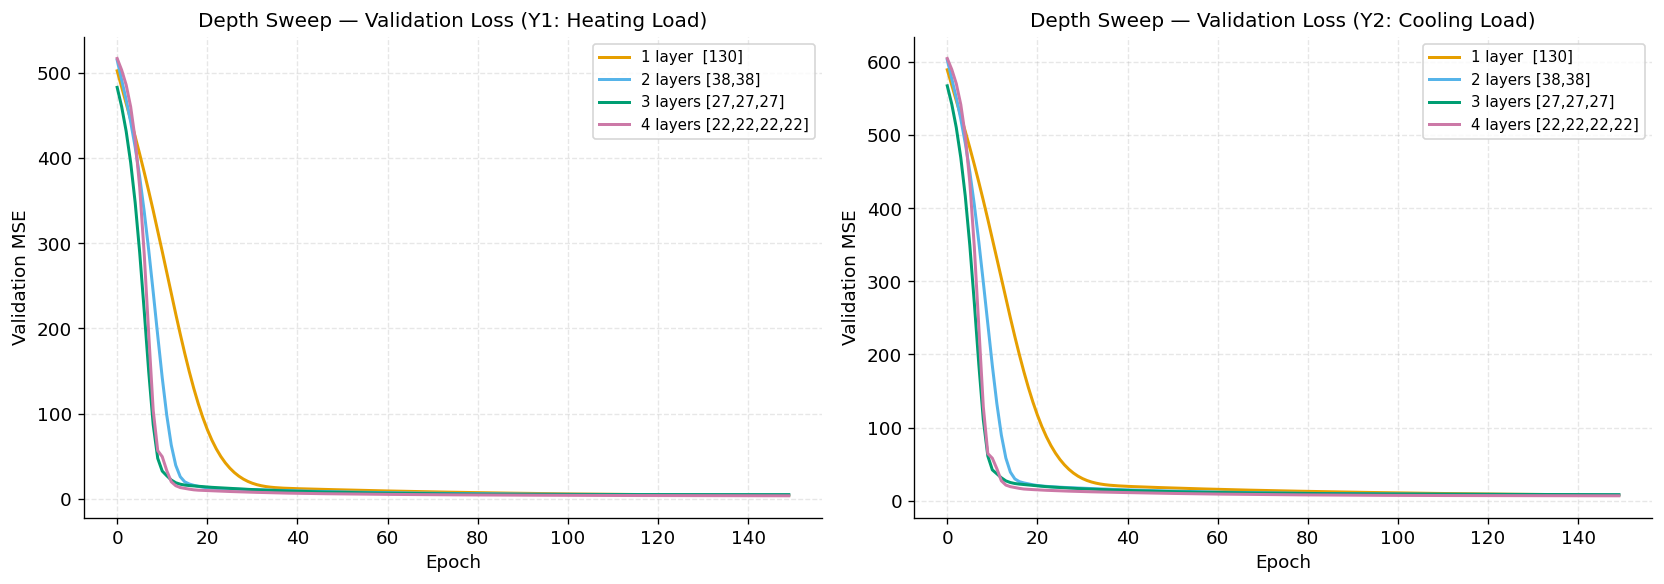

Saved: plot2_depth_loss_curves.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (name, res) in enumerate(depth_res_y1.items()):
    axes[0].plot(res["history"].history["val_loss"], label=name, color=DEPTH_COLOURS[idx])
axes[0].set_title("Depth Sweep — Validation Loss (Y1: Heating Load)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation MSE")
axes[0].grid(True, alpha=0.3, ls="--"); axes[0].legend()
axes[0].spines[["top","right"]].set_visible(False)

for idx, (name, res) in enumerate(depth_res_y2.items()):
    axes[1].plot(res["history"].history["val_loss"], label=name, color=DEPTH_COLOURS[idx])
axes[1].set_title("Depth Sweep — Validation Loss (Y2: Cooling Load)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation MSE")
axes[1].grid(True, alpha=0.3, ls="--"); axes[1].legend()
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot2_depth_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_depth_loss_curves.png")

## 9  Experiment 2 — Width Sweep

Here we fix depth at 2 layers and vary the number of neurons per layer. This isolates the effect of capacity through width.

**What to look for:** As width increases, parameter count rises quadratically. If performance improves proportionally, width is providing real benefit. If performance plateaus or reverses, we have hit diminishing returns — the extra capacity is being used to fit training noise rather than the true signal.

In [13]:
print("=" * 60)
print("WIDTH SWEEP")
print("=" * 60)
width_res_y1, width_res_y2 = {}, {}
for name, arch in WIDTH_ARCHS.items():
    r1 = train_architecture(arch, y1_train, y1_val)
    r2 = train_architecture(arch, y2_train, y2_val)
    width_res_y1[name] = r1; width_res_y2[name] = r2
    print(f"{name}: Y1 val={r1['best_val_mse']:.3f}  Y2 val={r2['best_val_mse']:.3f}  "
          f"epochs={r1['epochs_trained']}  params={r1['n_params']:,}")

width_rows = []
for name in WIDTH_ARCHS:
    r1, r2 = width_res_y1[name], width_res_y2[name]
    width_rows.append({"Architecture": name, "Params": r1["n_params"],
                       "Epochs Y1": r1["epochs_trained"],
                       "Train MSE Y1": r1["best_train_mse"],
                       "Val MSE Y1": r1["best_val_mse"],
                       "Gap Y1": r1["best_val_mse"]-r1["best_train_mse"],
                       "Epochs Y2": r2["epochs_trained"],
                       "Train MSE Y2": r2["best_train_mse"],
                       "Val MSE Y2": r2["best_val_mse"],
                       "Gap Y2": r2["best_val_mse"]-r2["best_train_mse"]})
width_summary = pd.DataFrame(width_rows).set_index("Architecture")
display(width_summary.round(3))

best_width_y1 = width_summary["Val MSE Y1"].idxmin()
best_width_y2 = width_summary["Val MSE Y2"].idxmin()
print(f"Best width model for Y1: {best_width_y1}")
print(f"Best width model for Y2: {best_width_y2}")

WIDTH SWEEP
Width 8: Y1 val=6.973  Y2 val=11.696  epochs=150  params=201
Width 32: Y1 val=5.170  Y2 val=8.724  epochs=150  params=1,569
Width 64: Y1 val=4.472  Y2 val=8.150  epochs=150  params=5,185
Width 128: Y1 val=4.607  Y2 val=8.356  epochs=95  params=18,561
Width 256: Y1 val=3.613  Y2 val=4.034  epochs=150  params=69,889


,Params,Epochs Y1,Train MSE Y1,Val MSE Y1,Gap Y1,Epochs Y2,Train MSE Y2,Val MSE Y2,Gap Y2
Architecture,,,,,,,,,
Width 8,201,150,10.442,6.973,-3.469,150,13.368,11.696,-1.672
Width 32,1569,150,7.150,5.170,-1.980,150,8.736,8.724,-0.012
Width 64,5185,150,6.698,4.472,-2.227,150,8.074,8.150,0.076
Width 128,18561,95,6.999,4.607,-2.392,98,8.347,8.356,0.009
Width 256,69889,150,4.339,3.613,-0.726,150,3.628,4.034,0.406


Best width model for Y1: Width 256
Best width model for Y2: Width 256


### Figure 3 — Parameter Count vs Validation MSE (Width Sweep)

*Alt text: Two scatter plots showing model parameter count on the x-axis and validation MSE on the y-axis. Points are labelled with their width value. Left: heating load. Right: cooling load.*

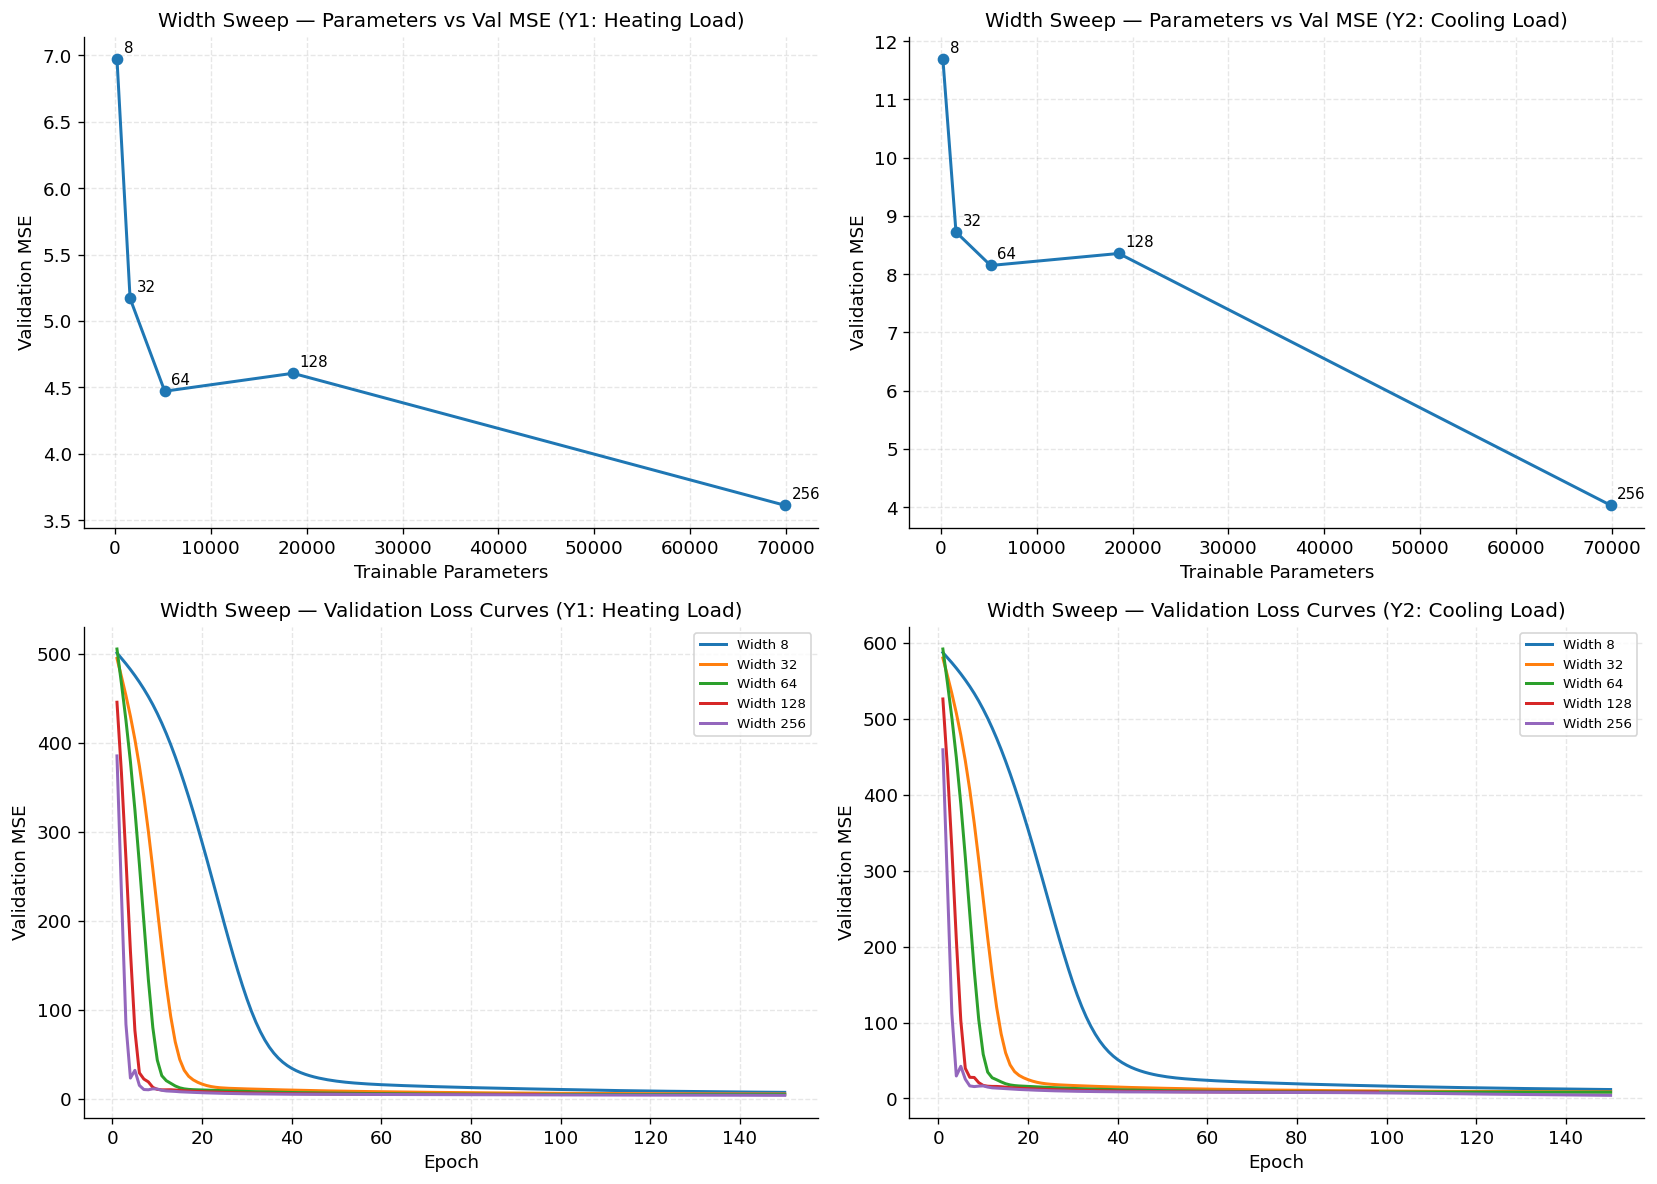

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, res_dict, title in [(axes[0,0], width_res_y1, "Y1: Heating Load"),
                             (axes[0,1], width_res_y2, "Y2: Cooling Load")]:
    xs = [res_dict[n]["n_params"] for n in WIDTH_ARCHS]
    ys = [res_dict[n]["best_val_mse"] for n in WIDTH_ARCHS]
    ax.plot(xs, ys, marker="o")
    for i, name in enumerate(WIDTH_ARCHS):
        ax.annotate(name.replace("Width ",""), (xs[i], ys[i]),
                    xytext=(4,4), textcoords="offset points", fontsize=9)
    ax.set_title(f"Width Sweep — Parameters vs Val MSE ({title})")
    ax.set_xlabel("Trainable Parameters"); ax.set_ylabel("Validation MSE")
    ax.grid(True, alpha=0.3, ls="--"); ax.spines[["top","right"]].set_visible(False)

for ax, res_dict, title in [(axes[1,0], width_res_y1, "Y1: Heating Load"),
                             (axes[1,1], width_res_y2, "Y2: Cooling Load")]:
    for name in WIDTH_ARCHS:
        hist = res_dict[name]["history"].history["val_loss"]
        ax.plot(range(1, len(hist)+1), hist, label=name)
    ax.set_title(f"Width Sweep — Validation Loss Curves ({title})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE")
    ax.grid(True, alpha=0.3, ls="--")
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot3_param_vs_valmse.png", dpi=150, bbox_inches="tight")
plt.show()

## 10  Experiment 3 — Depth × Width Grid

The grid gives a combined view of both factors. Instead of studying depth and width independently, we can see how they interact.

In [15]:
print("=" * 60)
print("DEPTH × WIDTH GRID")
print("=" * 60)
grid_val_y1    = np.zeros((len(GRID_DEPTHS), len(GRID_WIDTHS)))
grid_val_y2    = np.zeros_like(grid_val_y1)
grid_epochs_y1 = np.zeros((len(GRID_DEPTHS), len(GRID_WIDTHS)), dtype=int)
grid_epochs_y2 = np.zeros_like(grid_epochs_y1)
grid_train_y1  = np.zeros_like(grid_val_y1)
grid_train_y2  = np.zeros_like(grid_val_y1)
grid_results_y1, grid_results_y2 = {}, {}

for i, depth in enumerate(GRID_DEPTHS):
    for j, width in enumerate(GRID_WIDTHS):
        arch = [width] * depth
        label = f"Depth {depth} Width {width}"
        r1 = train_architecture(arch, y1_train, y1_val)
        r2 = train_architecture(arch, y2_train, y2_val)
        grid_results_y1[label] = {**r1, "arch": arch}
        grid_results_y2[label] = {**r2, "arch": arch}
        grid_val_y1[i,j]    = r1["best_val_mse"]
        grid_val_y2[i,j]    = r2["best_val_mse"]
        grid_train_y1[i,j]  = r1["best_train_mse"]
        grid_train_y2[i,j]  = r2["best_train_mse"]
        grid_epochs_y1[i,j] = r1["epochs_trained"]
        grid_epochs_y2[i,j] = r2["epochs_trained"]
        print(f"depth={depth} width={width}  Y1={r1['best_val_mse']:.3f}  Y2={r2['best_val_mse']:.3f}")

best_grid_y1 = min(grid_results_y1, key=lambda k: grid_results_y1[k]["best_val_mse"])
best_grid_y2 = min(grid_results_y2, key=lambda k: grid_results_y2[k]["best_val_mse"])
print(f"Best grid model for Y1: {best_grid_y1}")
print(f"Best grid model for Y2: {best_grid_y2}")

DEPTH × WIDTH GRID
depth=1 width=32  Y1=8.131  Y2=13.167
depth=1 width=64  Y1=6.269  Y2=10.317
depth=1 width=128  Y1=4.370  Y2=7.380
depth=2 width=32  Y1=5.170  Y2=8.724
depth=2 width=64  Y1=4.472  Y2=8.150
depth=2 width=128  Y1=4.607  Y2=8.356
depth=3 width=32  Y1=5.387  Y2=8.306
depth=3 width=64  Y1=2.571  Y2=5.378
depth=3 width=128  Y1=2.011  Y2=4.677
Best grid model for Y1: Depth 3 Width 128
Best grid model for Y2: Depth 3 Width 128


### Figure 4 — Depth × Width Heatmaps

*Alt text: Four heatmaps arranged in a 2×2 grid. Top row: validation MSE for Y1 and Y2. Bottom row: epochs trained for Y1 and Y2. Rows represent depth (1–3), columns represent width (32–64–128). Each cell is annotated with its numeric value.*

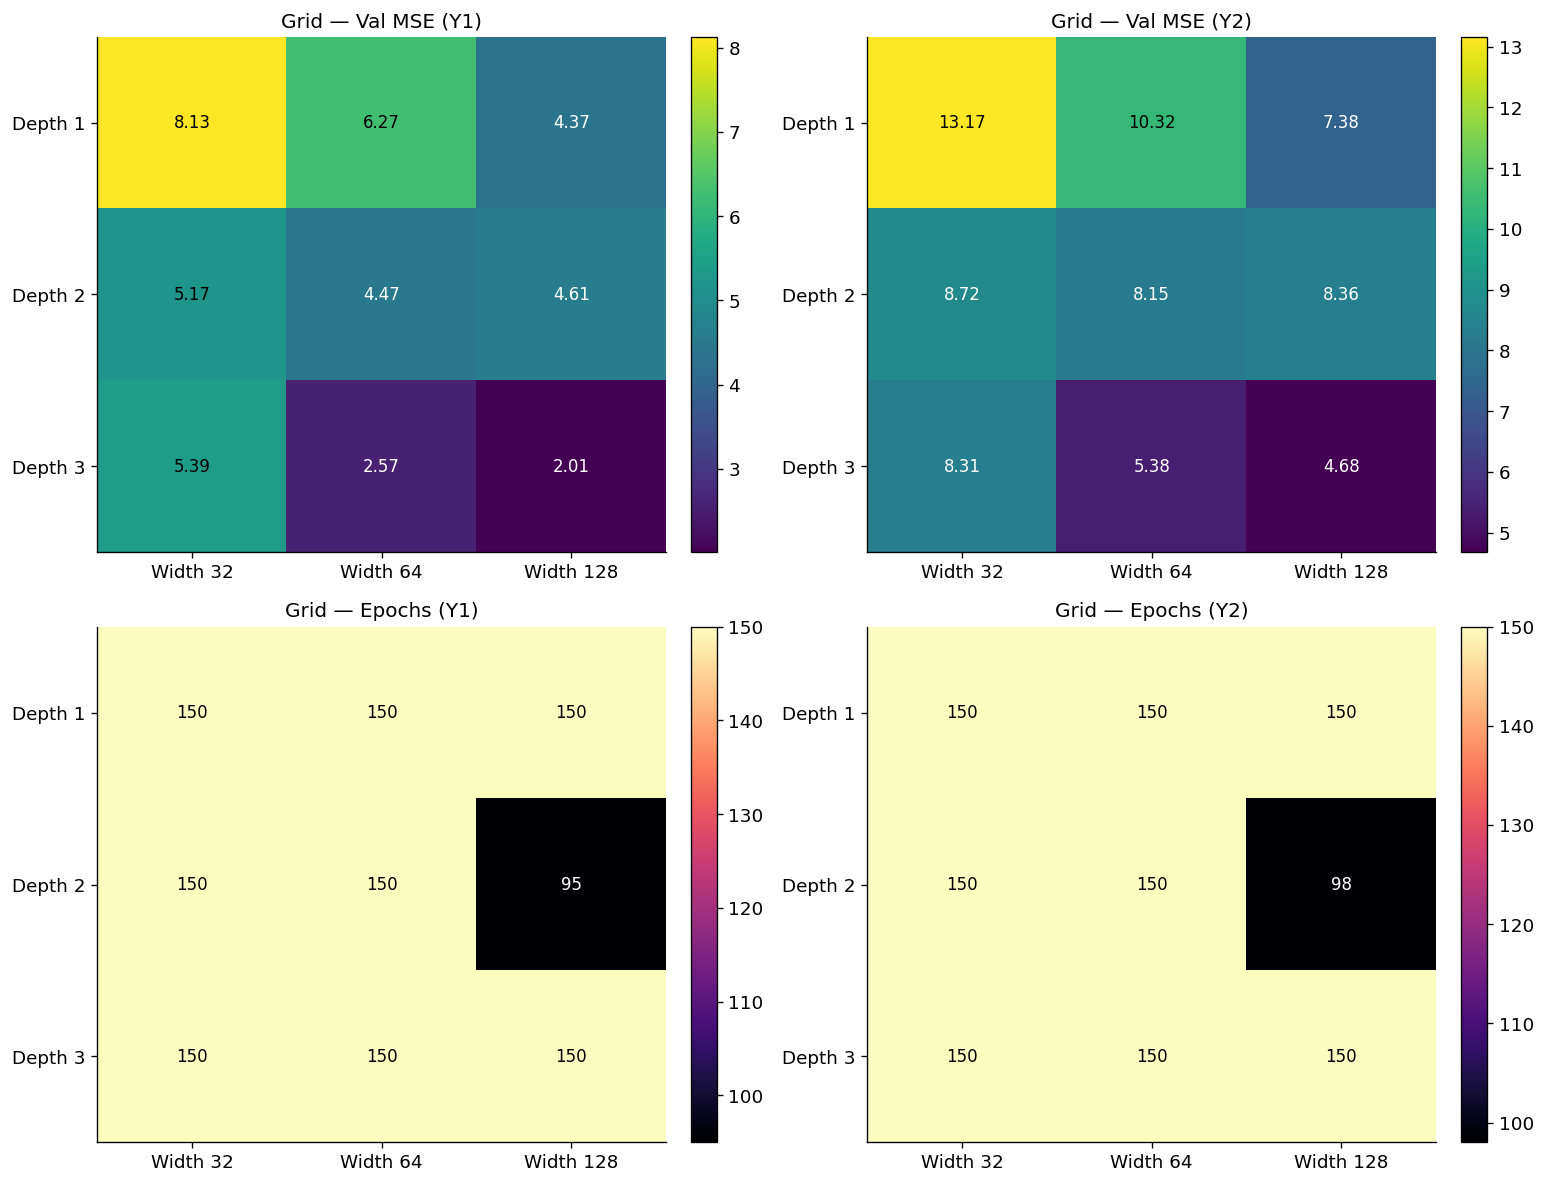

In [27]:
def annotated_heatmap(ax, data, rows, cols, title, cmap="viridis", fmt=".2f"):
    im = ax.imshow(data, cmap=cmap, aspect="auto")
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(rows)
    ax.set_title(title)

    # Normalize values to decide whether text should be black or white
    norm = im.norm

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data[i, j]
            text_color = "white" if norm(value) < 0.5 else "black"
            ax.text(
                j, i, format(value, fmt),
                ha="center",
                va="center",
                color=text_color,
                fontsize=10
            )
    return im


fig, axes = plt.subplots(2, 2, figsize=(13, 10))

rl = [f"Depth {d}" for d in GRID_DEPTHS]
cl = [f"Width {w}" for w in GRID_WIDTHS]

for (ax, data, title, cmap, fmt) in [
    (axes[0, 0], grid_val_y1,    "Val MSE (Y1)", "viridis", ".2f"),
    (axes[0, 1], grid_val_y2,    "Val MSE (Y2)", "viridis", ".2f"),
    (axes[1, 0], grid_epochs_y1, "Epochs (Y1)",  "magma",   "d"),
    (axes[1, 1], grid_epochs_y2, "Epochs (Y2)",  "magma",   "d"),
]:
    im = annotated_heatmap(ax, data, rl, cl, f"Grid — {title}", cmap, fmt)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot4_grid_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 figure 5 Overfitting Gap Analysis

The **train–validation gap** = validation MSE − training MSE. A larger gap means the model fits training data better than it generalises. This is a hallmark of overfitting.

**What to expect:** Deeper networks (with the same parameter count) tend to have a higher gap. More layers create more opportunities for the network to memorise quirks of the training set.

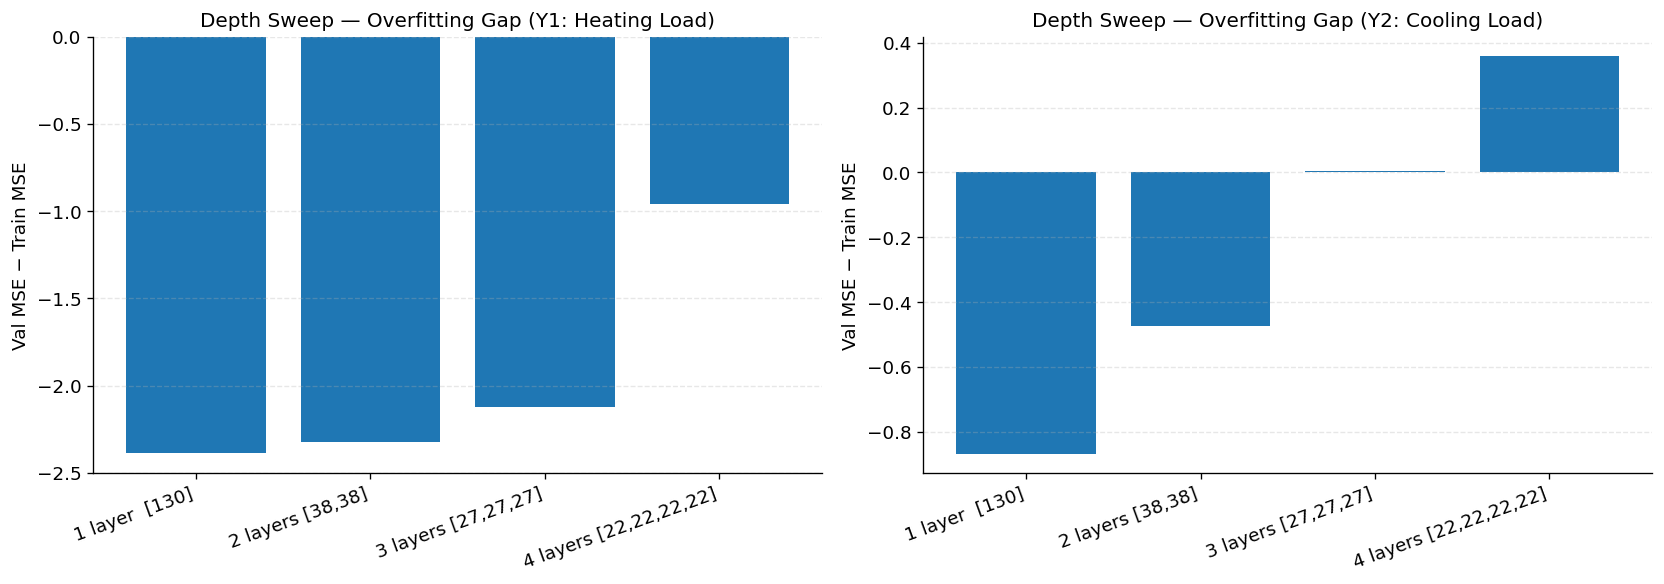

Interpretation: Positive gaps suggest validation error exceeds training error, which can indicate overfitting. In this experiment the gaps are small and should be interpreted cautiously.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(depth_summary.index))
for ax, col, title in [(axes[0], "Gap Y1", "Overfitting Gap (Y1: Heating Load)"),
                        (axes[1], "Gap Y2", "Overfitting Gap (Y2: Cooling Load)")]:
    ax.bar(x, depth_summary[col].values)
    ax.set_xticks(x); ax.set_xticklabels(depth_summary.index, rotation=20, ha="right")
    ax.set_title(f"Depth Sweep — {title}")
    ax.set_ylabel("Val MSE − Train MSE")
    ax.grid(True, axis="y", alpha=0.3, ls="--")
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("plot5_overfitting_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interpretation: Positive gaps suggest validation error exceeds training error, which can indicate overfitting. In this experiment the gaps are small and should be interpreted cautiously.")

## 12  Gradient Norm Analysis

This section probes gradient magnitudes at each layer after a short warm-up. The motivation is to illustrate whether early layers suffer from weaker learning signals as depth increases — a form of the vanishing gradient problem even with ReLU.

**How it works:** We compute the L2 norm of the gradient of the loss with respect to each layer's weight matrix, averaged over 15 mini-batches. A declining norm from last layer to first layer indicates signal attenuation.

>  This is illustrative, not a formal proof. With only 4 layers and ReLU activations, full vanishing is unlikely. The purpose is to build intuition.

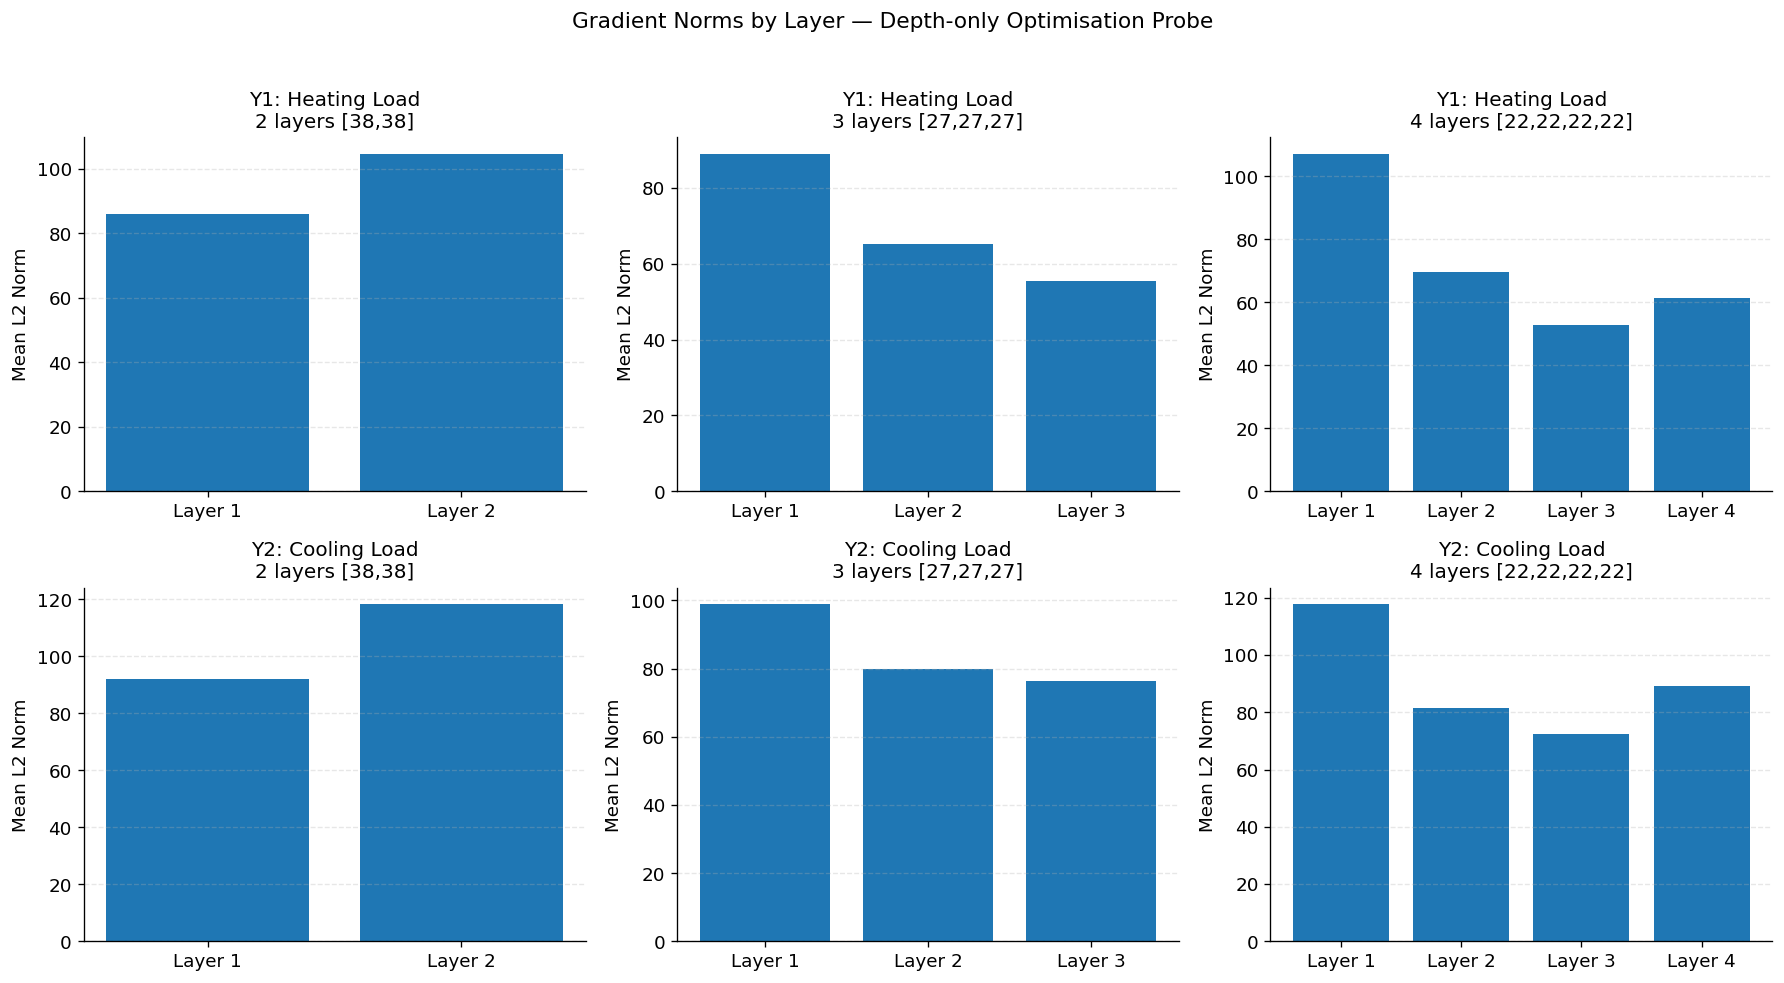

This probe is intentionally focused on depth. It illustrates how gradient magnitudes are distributed across layers for the same family of depth-sweep models on both targets.


In [18]:
def get_gradient_norms(arch, y_task, warmup=10, n_batches=15, seed=SEED):
    set_all_seeds(seed)
    model = build_model(arch, seed=seed)
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
    model.fit(X_train, y_task, epochs=warmup, batch_size=BATCH_SIZE, verbose=0)

    kernels = [
        l.kernel for l in model.layers
        if isinstance(l, layers.Dense) and l.name != "output"
    ]
    collector = [[] for _ in kernels]
    loss_fn = keras.losses.MeanSquaredError()

    ds = tf.data.Dataset.from_tensor_slices((X_train, y_task)).batch(BATCH_SIZE).take(n_batches)

    for Xb, yb in ds:
        with tf.GradientTape() as tape:
            preds = model(Xb, training=True)
            loss = loss_fn(tf.cast(yb, tf.float32), preds)
        grads = tape.gradient(loss, kernels)

        for i, g in enumerate(grads):
            if g is not None:
                collector[i].append(float(tf.norm(g).numpy()))

    layer_names = [f"Layer {i+1}" for i in range(len(kernels))]
    mean_norms = [np.mean(c) if c else 0.0 for c in collector]
    return layer_names, mean_norms


configs = {
    "2 layers [38,38]": [38, 38],
    "3 layers [27,27,27]": [27, 27, 27],
    "4 layers [22,22,22,22]": [22, 22, 22, 22]
}

grad_results_y1 = {n: get_gradient_norms(a, y1_train) for n, a in configs.items()}
grad_results_y2 = {n: get_gradient_norms(a, y2_train) for n, a in configs.items()}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for row, grad_results, task_name in [
    (0, grad_results_y1, "Y1: Heating Load"),
    (1, grad_results_y2, "Y2: Cooling Load")
]:
    for ax, (name, (lnames, norms)) in zip(axes[row], grad_results.items()):
        ax.bar(lnames, norms)
        ax.set_title(f"{task_name}\n{name}")
        ax.set_ylabel("Mean L2 Norm")
        ax.grid(True, axis="y", alpha=0.3, ls="--")
        ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Gradient Norms by Layer — Depth-only Optimisation Probe", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("plot6_gradient_norms.png", dpi=150, bbox_inches="tight")
plt.show()

print("This probe is intentionally focused on depth. It illustrates how gradient magnitudes are distributed across layers for the same family of depth-sweep models on both targets.")

## 12  Selecting the Final Architecture Fairly

Instead of choosing the final model from the depth sweep only, compare the best candidate from the depth sweep, width sweep and grid search, then select the overall winner on validation MSE for each target.

In [19]:
candidate_models_y1 = {
    f"Depth sweep — {best_depth_y1}": {"arch": DEPTH_ARCHS[best_depth_y1], "val_mse": depth_summary.loc[best_depth_y1, "Val MSE Y1"], "family": "depth"},
    f"Width sweep — {best_width_y1}": {"arch": WIDTH_ARCHS[best_width_y1], "val_mse": width_summary.loc[best_width_y1, "Val MSE Y1"], "family": "width"},
    f"Grid search — {best_grid_y1}": {"arch": grid_results_y1[best_grid_y1]["arch"], "val_mse": grid_results_y1[best_grid_y1]["best_val_mse"], "family": "grid"},
}
candidate_models_y2 = {
    f"Depth sweep — {best_depth_y2}": {"arch": DEPTH_ARCHS[best_depth_y2], "val_mse": depth_summary.loc[best_depth_y2, "Val MSE Y2"], "family": "depth"},
    f"Width sweep — {best_width_y2}": {"arch": WIDTH_ARCHS[best_width_y2], "val_mse": width_summary.loc[best_width_y2, "Val MSE Y2"], "family": "width"},
    f"Grid search — {best_grid_y2}": {"arch": grid_results_y2[best_grid_y2]["arch"], "val_mse": grid_results_y2[best_grid_y2]["best_val_mse"], "family": "grid"},
}

best_overall_y1_name = min(candidate_models_y1, key=lambda k: candidate_models_y1[k]["val_mse"])
best_overall_y2_name = min(candidate_models_y2, key=lambda k: candidate_models_y2[k]["val_mse"])
best_overall_y1 = candidate_models_y1[best_overall_y1_name]
best_overall_y2 = candidate_models_y2[best_overall_y2_name]

print("Overall winner for Y1:", best_overall_y1_name, "->", best_overall_y1["arch"], f"(val MSE={best_overall_y1['val_mse']:.3f})")
print("Overall winner for Y2:", best_overall_y2_name, "->", best_overall_y2["arch"], f"(val MSE={best_overall_y2['val_mse']:.3f})")

Overall winner for Y1: Grid search — Depth 3 Width 128 -> [128, 128, 128] (val MSE=2.011)
Overall winner for Y2: Width sweep — Width 256 -> [256, 256] (val MSE=4.034)


## 13  Multi-Seed Robustness

A single training run gives a *point estimate* of performance. Because neural network initialisation is random, the same architecture with a different seed may give a meaningfully different result — especially on small datasets (768 samples).

**Best practice:** Run the same architecture with 3–5 different seeds and report mean ± standard deviation. If the standard deviation is large relative to the mean, treat results with caution.

In [20]:
robust_y1 = run_multiple_seeds(best_overall_y1["arch"], y1_train, y1_val)
robust_y2 = run_multiple_seeds(best_overall_y2["arch"], y2_train, y2_val)

print(f"Y1 best overall arch: {best_overall_y1_name}")
print(f"  Val MSE per seed: {[round(v,3) for v in robust_y1['val_scores']]}")
print(f"  Mean ± SD: {robust_y1['val_mean']:.3f} ± {robust_y1['val_std']:.3f}")
print(f" Y2 best overall arch: {best_overall_y2_name}")
print(f"  Val MSE per seed: {[round(v,3) for v in robust_y2['val_scores']]}")
print(f"  Mean ± SD: {robust_y2['val_mean']:.3f} ± {robust_y2['val_std']:.3f}")

Y1 best overall arch: Grid search — Depth 3 Width 128
  Val MSE per seed: [1.054, 0.556, 2.011, 1.437, 1.181]
  Mean ± SD: 1.248 ± 0.477
 Y2 best overall arch: Width sweep — Width 256
  Val MSE per seed: [7.029, 8.509, 4.034, 6.888, 7.275]
  Mean ± SD: 6.747 ± 1.473


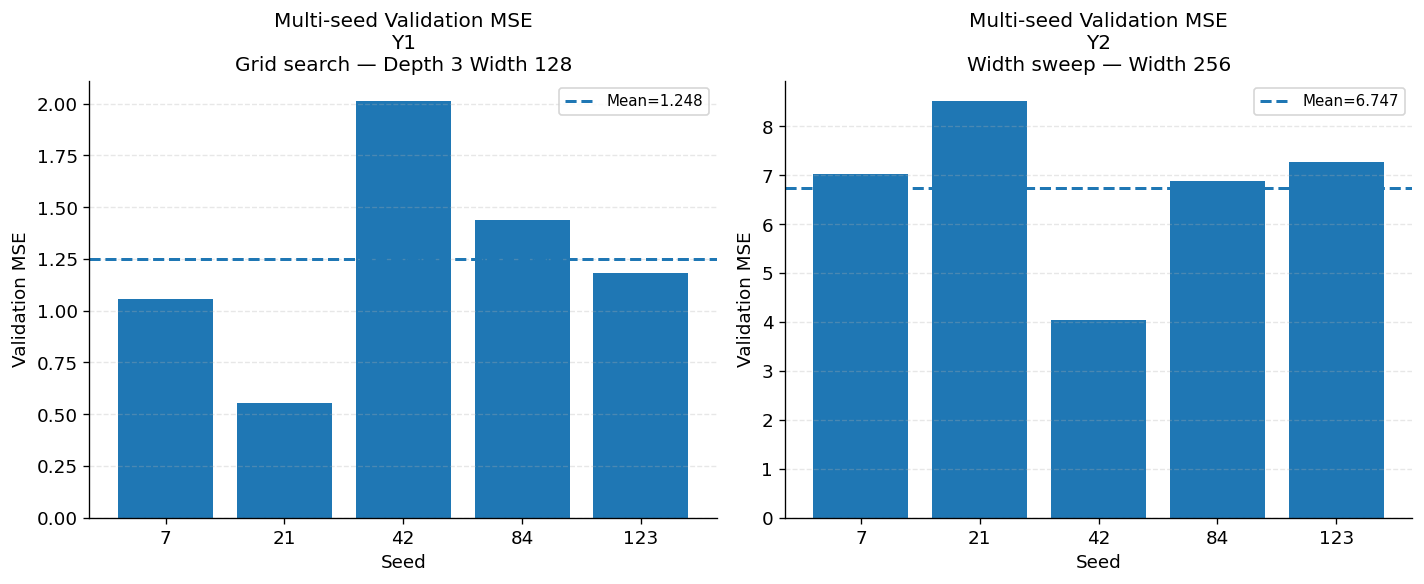

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, robust, title in [
    (axes[0], robust_y1, f"Y1\n{best_overall_y1_name}"),
    (axes[1], robust_y2, f"Y2\n{best_overall_y2_name}")
]:
    ax.bar([str(s) for s in ROBUSTNESS_SEEDS], robust["val_scores"])
    ax.axhline(robust["val_mean"], ls="--", label=f'Mean={robust["val_mean"]:.3f}')

    ax.set_title(f"Multi-seed Validation MSE\n{title}")
    ax.set_xlabel("Seed")
    ax.set_ylabel("Validation MSE")

    ax.legend()
    ax.grid(True, axis="y", alpha=0.3, ls="--")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot7_multiseed.png", dpi=150, bbox_inches="tight")
plt.show()

## 14  Final Test Evaluation

The test set has been **completely untouched** until now. This is the single, honest evaluation of the selected architecture.

**Procedure:**
1. Select best architecture using validation data only ✓ (done above)
2. Retrain on train + validation combined (more non-test data)
3. Evaluate on the test set — **once**

In [22]:
def train_final_model(arch, X_trval, y_trval, X_te_raw, seed=SEED):
    set_all_seeds(seed)
    # Refit the scaler on all non-test data for the final model.
    scaler_final = StandardScaler()
    X_trval_scaled = scaler_final.fit_transform(X_trval)
    X_te_scaled = scaler_final.transform(X_te_raw)

    Xs, Xv, ys, yv = train_test_split(X_trval_scaled, y_trval, test_size=0.15, random_state=seed)
    model = build_model(arch, n_features=X_trval_scaled.shape[1], seed=seed)
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse", metrics=["mae"])
    cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                       restore_best_weights=True, min_delta=1e-4)
    model.fit(Xs, ys, validation_data=(Xv, yv), epochs=MAX_EPOCHS,
              batch_size=BATCH_SIZE, callbacks=[cb], verbose=0)
    return model, X_te_scaled

def eval_baseline_test(model, Xtrval, ytrval, Xte_raw, yte):
    scaler_b = StandardScaler()
    Xtrval_scaled = scaler_b.fit_transform(Xtrval)
    Xte_scaled = scaler_b.transform(Xte_raw)
    model.fit(Xtrval_scaled, ytrval)
    preds = model.predict(Xte_scaled)
    return float(mean_squared_error(yte, preds))

X_trainval_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y1_trainval = np.concatenate([y1_train, y1_val])
y2_trainval = np.concatenate([y2_train, y2_val])

fm_y1, X_test_final_y1 = train_final_model(best_overall_y1["arch"], X_trainval_raw, y1_trainval, X_test_raw)
fm_y2, X_test_final_y2 = train_final_model(best_overall_y2["arch"], X_trainval_raw, y2_trainval, X_test_raw)

def test_eval(model, X_te_scaled, y_te):
    p = model.predict(X_te_scaled, verbose=0).flatten()
    return float(mean_squared_error(y_te, p)), p

test_mse_y1, y1_pred = test_eval(fm_y1, X_test_final_y1, y1_test)
test_mse_y2, y2_pred = test_eval(fm_y2, X_test_final_y2, y2_test)

# Final baseline comparison on test set — performed only here.
from sklearn.base import clone
baseline_test_rows = []
for name, mdl in baselines.items():
    baseline_test_rows.append({
        "Model": name,
        "Test MSE Y1": eval_baseline_test(clone(mdl), X_trainval_raw, y1_trainval, X_test_raw, y1_test),
        "Test MSE Y2": eval_baseline_test(clone(mdl), X_trainval_raw, y2_trainval, X_test_raw, y2_test),
    })
baseline_test_df = pd.DataFrame(baseline_test_rows).set_index("Model")
display(baseline_test_df.round(3))
BEST_BASELINE_TEST_Y1 = baseline_test_df["Test MSE Y1"].min()
BEST_BASELINE_TEST_Y2 = baseline_test_df["Test MSE Y2"].min()
BEST_BASELINE_TEST_NAME_Y1 = baseline_test_df["Test MSE Y1"].idxmin()
BEST_BASELINE_TEST_NAME_Y2 = baseline_test_df["Test MSE Y2"].idxmin()

print(f"{'':40s} {'Y1':>10} {'Y2':>10}")
print(f"{'Selected MLP family':40s} {best_overall_y1['family']:>10} {best_overall_y2['family']:>10}")
print(f"{'Selected MLP architecture':40s} {str(best_overall_y1['arch']):>10} {str(best_overall_y2['arch']):>10}")
print(f"{'MLP Test MSE':40s} {test_mse_y1:>10.3f} {test_mse_y2:>10.3f}")
print(f"{'Best Baseline Test MSE':40s} {BEST_BASELINE_TEST_Y1:>10.3f} {BEST_BASELINE_TEST_Y2:>10.3f}")
print(f"{'Best baseline name':40s} {BEST_BASELINE_TEST_NAME_Y1:>10} {BEST_BASELINE_TEST_NAME_Y2:>10}")
print(f"{'MLP improvement over best baseline':40s} {BEST_BASELINE_TEST_Y1-test_mse_y1:>+10.3f} {BEST_BASELINE_TEST_Y2-test_mse_y2:>+10.3f}")

,Test MSE Y1,Test MSE Y2
Model,,
Linear Regression,8.978,9.629
Ridge (α=1),9.017,9.667
Ridge (α=10),9.315,10.114
Random Forest,0.267,3.995


                                                 Y1         Y2
Selected MLP family                            grid      width
Selected MLP architecture                [128, 128, 128] [256, 256]
MLP Test MSE                                 10.987     11.101
Best Baseline Test MSE                        0.267      3.995
Best baseline name                       Random Forest Random Forest
MLP improvement over best baseline          -10.720     -7.106


## 15  Residual Analysis

Residual plots check for systematic prediction errors. A well-behaved model should show residuals that are:
- Centred around zero (unbiased)
- Homoscedastic (roughly equal spread across all predicted values)
- No clear pattern (the model has captured all learnable structure)

*Alt text: Left — scatter plot of residuals (y-axis) against predicted heating load (x-axis), with a horizontal dashed line at zero. Right — histogram of residuals centred approximately at zero.*

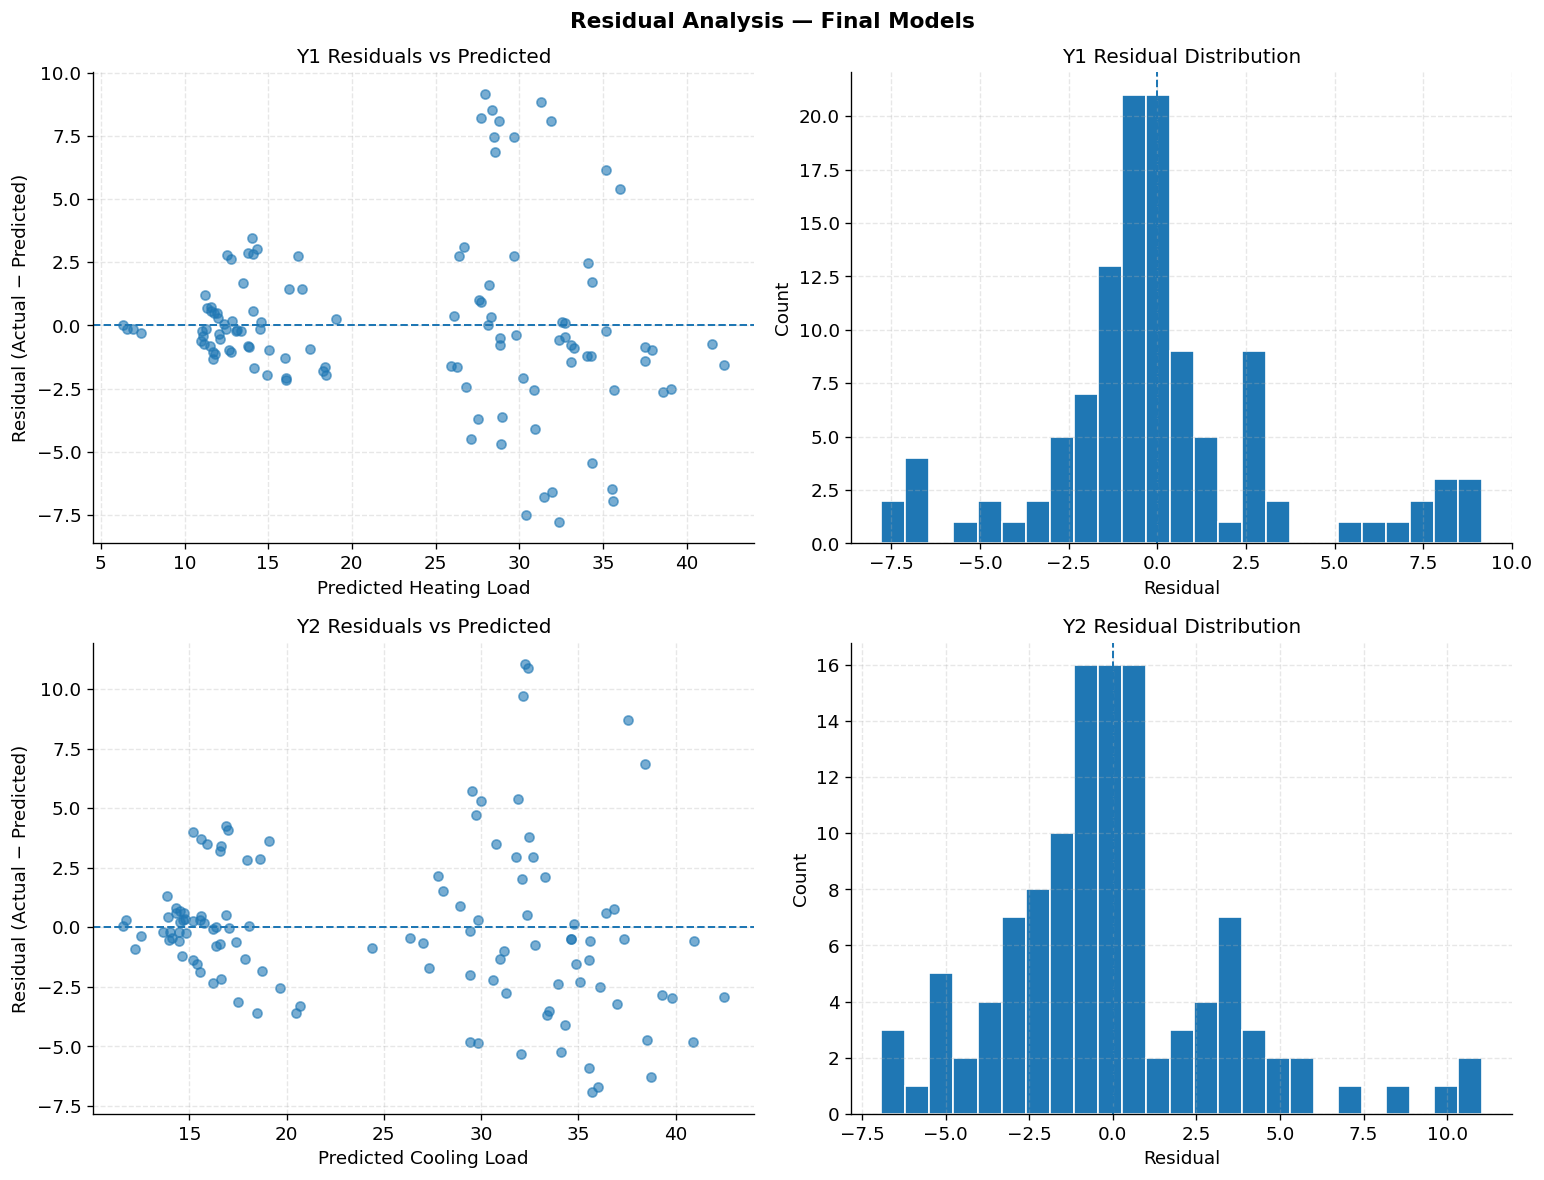

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Residual Analysis — Final Models", fontsize=13, fontweight="bold")

residuals_y1 = y1_test - y1_pred
axes[0,0].scatter(y1_pred, residuals_y1, alpha=0.6, s=30)
axes[0,0].axhline(0, ls="--", lw=1.2)
axes[0,0].set_title("Y1 Residuals vs Predicted")
axes[0,0].set_xlabel("Predicted Heating Load")
axes[0,0].set_ylabel("Residual (Actual − Predicted)")
axes[0,0].grid(True, alpha=0.3, ls="--"); axes[0,0].spines[["top","right"]].set_visible(False)

axes[0,1].hist(residuals_y1, bins=25, edgecolor="white")
axes[0,1].axvline(0, ls="--", lw=1.2)
axes[0,1].set_title("Y1 Residual Distribution")
axes[0,1].set_xlabel("Residual")
axes[0,1].set_ylabel("Count")
axes[0,1].grid(True, alpha=0.3, ls="--"); axes[0,1].spines[["top","right"]].set_visible(False)

residuals_y2 = y2_test - y2_pred
axes[1,0].scatter(y2_pred, residuals_y2, alpha=0.6, s=30)
axes[1,0].axhline(0, ls="--", lw=1.2)
axes[1,0].set_title("Y2 Residuals vs Predicted")
axes[1,0].set_xlabel("Predicted Cooling Load")
axes[1,0].set_ylabel("Residual (Actual − Predicted)")
axes[1,0].grid(True, alpha=0.3, ls="--"); axes[1,0].spines[["top","right"]].set_visible(False)

axes[1,1].hist(residuals_y2, bins=25, edgecolor="white")
axes[1,1].axvline(0, ls="--", lw=1.2)
axes[1,1].set_title("Y2 Residual Distribution")
axes[1,1].set_xlabel("Residual")
axes[1,1].set_ylabel("Count")
axes[1,1].grid(True, alpha=0.3, ls="--"); axes[1,1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot8_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

Best Model Comparison (Bar Chart)

,Model family,Y1 Val MSE,Y2 Val MSE
0,Best baseline,0.196,1.582
1,Best depth sweep,3.689,6.745
2,Best width sweep,3.613,4.034
3,Best grid model,2.011,4.677


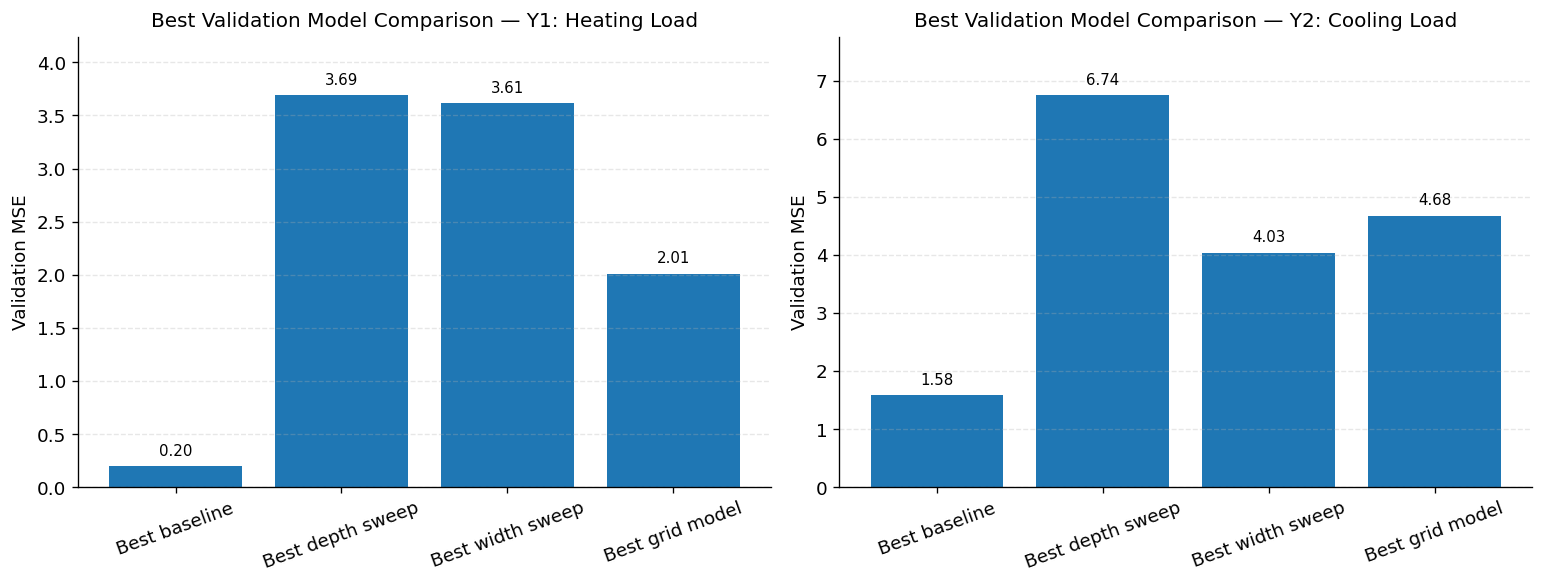

Best overall Y1 family: baseline 0.19577029353448305
Best overall Y2 family: baseline 1.5824742132758582


In [24]:
comparison_df = pd.DataFrame({
    "Model family": ["Best baseline", "Best depth sweep", "Best width sweep", "Best grid model"],
    "Y1 Val MSE": [
        BEST_BASELINE_VAL_Y1,
        depth_summary.loc[best_depth_y1, "Val MSE Y1"],
        width_summary.loc[best_width_y1, "Val MSE Y1"],
        grid_results_y1[best_grid_y1]["best_val_mse"],
    ],
    "Y2 Val MSE": [
        BEST_BASELINE_VAL_Y2,
        depth_summary.loc[best_depth_y2, "Val MSE Y2"],
        width_summary.loc[best_width_y2, "Val MSE Y2"],
        grid_results_y2[best_grid_y2]["best_val_mse"],
    ]
})

display(comparison_df.round(3))
comparison_df.to_csv("best_model_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "Y1 Val MSE", "Y1: Heating Load"),
    (axes[1], "Y2 Val MSE", "Y2: Cooling Load")
]:
    vals = comparison_df[col].values
    labels = comparison_df["Model family"].values
    bars = ax.bar(labels, vals)

    ax.set_title(f"Best Validation Model Comparison — {title}")
    ax.set_ylabel("Validation MSE")
    ax.set_ylim(0, max(vals) * 1.15)
    ax.grid(True, axis="y", alpha=0.3, ls="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=20)

    for b, v in zip(bars, vals):
        ax.text(
            b.get_x() + b.get_width() / 2,
            v + max(vals) * 0.02,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("plot9_best_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

overall_candidates_y1 = {
    "baseline": BEST_BASELINE_VAL_Y1,
    "depth": depth_summary.loc[best_depth_y1, "Val MSE Y1"],
    "width": width_summary.loc[best_width_y1, "Val MSE Y1"],
    "grid": grid_results_y1[best_grid_y1]["best_val_mse"],
}

overall_candidates_y2 = {
    "baseline": BEST_BASELINE_VAL_Y2,
    "depth": depth_summary.loc[best_depth_y2, "Val MSE Y2"],
    "width": width_summary.loc[best_width_y2, "Val MSE Y2"],
    "grid": grid_results_y2[best_grid_y2]["best_val_mse"],
}

best_overall_y1_family = min(overall_candidates_y1, key=overall_candidates_y1.get)
best_overall_y2_family = min(overall_candidates_y2, key=overall_candidates_y2.get)

print("Best overall Y1 family:", best_overall_y1_family, overall_candidates_y1[best_overall_y1_family])
print("Best overall Y2 family:", best_overall_y2_family, overall_candidates_y2[best_overall_y2_family])

## 16  Save All Outputs

In [25]:
baseline_df.to_csv("baseline_summary.csv")
baseline_test_df.to_csv("baseline_test_summary.csv")
depth_summary.to_csv("depth_summary.csv")
width_summary.to_csv("width_summary.csv")
comparison_df.to_csv("best_model_comparison.csv", index=False)

grid_rows = [{"Depth": GRID_DEPTHS[i], "Width": GRID_WIDTHS[j],
              "Val MSE Y1": grid_val_y1[i,j], "Val MSE Y2": grid_val_y2[i,j],
              "Train MSE Y1": grid_train_y1[i,j], "Train MSE Y2": grid_train_y2[i,j],
              "Epochs Y1": grid_epochs_y1[i,j], "Epochs Y2": grid_epochs_y2[i,j]}
             for i in range(len(GRID_DEPTHS)) for j in range(len(GRID_WIDTHS))]
pd.DataFrame(grid_rows).to_csv("grid_summary.csv", index=False)

pd.DataFrame([{
    "Best Depth Arch Y1": best_depth_y1, "Best Depth Arch Y2": best_depth_y2,
    "Best Width Arch Y1": best_width_y1, "Best Width Arch Y2": best_width_y2,
    "Best Grid Arch Y1": best_grid_y1, "Best Grid Arch Y2": best_grid_y2,
    "Best Overall Arch Y1": best_overall_y1_name, "Best Overall Arch Y2": best_overall_y2_name,
    "Final Test MSE Y1": test_mse_y1, "Final Test MSE Y2": test_mse_y2,
    "Best Baseline Test MSE Y1": BEST_BASELINE_TEST_Y1,
    "Best Baseline Test MSE Y2": BEST_BASELINE_TEST_Y2,
    "Robustness Mean Y1": robust_y1["val_mean"], "Robustness Std Y1": robust_y1["val_std"],
    "Robustness Mean Y2": robust_y2["val_mean"], "Robustness Std Y2": robust_y2["val_std"],
}]).to_csv("final_results.csv", index=False)

print("All outputs saved:")
for f in ["baseline_summary.csv","baseline_test_summary.csv","depth_summary.csv","width_summary.csv",
          "grid_summary.csv","best_model_comparison.csv","final_results.csv",
          "plot0_architecture_diagram.png","plot1_depth_loss_curves.png","plot2_param_vs_valmse.png",
          "plot3_grid_heatmaps.png","plot4_overfitting_gap.png",
          "plot5_gradient_norms.png","plot6_multiseed.png","plot7_residuals.png",
          "plot8_best_model_comparison.png"]:
    print(" ", f)

All outputs saved:
  baseline_summary.csv
  baseline_test_summary.csv
  depth_summary.csv
  width_summary.csv
  grid_summary.csv
  best_model_comparison.csv
  final_results.csv
  plot0_architecture_diagram.png
  plot1_depth_loss_curves.png
  plot2_param_vs_valmse.png
  plot3_grid_heatmaps.png
  plot4_overfitting_gap.png
  plot5_gradient_norms.png
  plot6_multiseed.png
  plot7_residuals.png
  plot8_best_model_comparison.png
